In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
df = pd.read_csv("../outputs/engineered_house_prices.csv")

df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice,TotalLivingArea,HouseAge,TotalPorchSF,HasGarage,HasSecondFloor
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,856,0.0,2003,2003,208500,2566,0,61.0,1,1
1,1262,0.0,3.0,Gd,978,ALQ,284,0.0,460,RFn,...,1262,0.0,1976,1976,181500,2524,0,0.0,1,0
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,920,0.0,2001,2002,223500,2706,1,42.0,1,1
3,961,0.0,3.0,No,216,ALQ,540,0.0,642,Unf,...,756,0.0,1915,1970,140000,2473,55,35.0,1,0
4,1145,0.0,4.0,Av,655,GLQ,490,0.0,836,RFn,...,1145,0.0,2000,2000,250000,3343,0,84.0,1,0


In [3]:
df.shape

(1460, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   1stFlrSF         1460 non-null   int64  
 1   2ndFlrSF         1460 non-null   float64
 2   BedroomAbvGr     1460 non-null   float64
 3   BsmtExposure     1460 non-null   object 
 4   BsmtFinSF1       1460 non-null   int64  
 5   BsmtFinType1     1460 non-null   object 
 6   BsmtUnfSF        1460 non-null   int64  
 7   EnclosedPorch    1460 non-null   float64
 8   GarageArea       1460 non-null   int64  
 9   GarageFinish     1460 non-null   object 
 10  GarageYrBlt      1460 non-null   float64
 11  GrLivArea        1460 non-null   int64  
 12  KitchenQual      1460 non-null   object 
 13  LotArea          1460 non-null   int64  
 14  LotFrontage      1460 non-null   float64
 15  MasVnrArea       1460 non-null   float64
 16  OpenPorchSF      1460 non-null   int64  
 17  OverallCond   

## Encode Categorical Variables

In [5]:
df = pd.get_dummies(df, drop_first=True)

df.shape

(1460, 38)

## Split Features and Target

In [6]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 37)
(1460,)


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 37)
(292, 37)


## Train Linear Regression Model

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Make Predictions

In [9]:
predictions = model.predict(X_test)

predictions[:5]

array([152640.82546705, 271049.48300612, 106598.48802345, 153586.67331557,
       339096.74709136])

## Model Evaluation

In [10]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 21242.82
Root Mean Squared Error: 34178.36
R² Score: 0.8477


In [11]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")

Training R² Score: 0.8141
Test R² Score: 0.8477


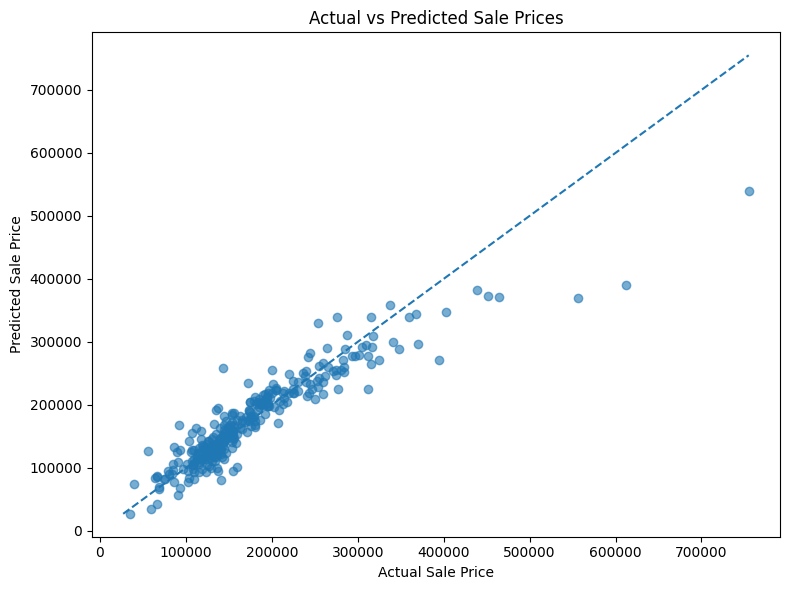

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, test_predictions, alpha=0.6)

minimum = min(y_test.min(), test_predictions.min())
maximum = max(y_test.max(), test_predictions.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

ax.set_xlabel("Actual Sale Price")
ax.set_ylabel("Predicted Sale Price")
ax.set_title("Actual vs Predicted Sale Prices")

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Actual vs Predicted Interpretation

Most predicted values are positioned close to the diagonal reference line,
showing that the model produces reasonably accurate estimates for the majority
of properties.

The model performs particularly well for houses in the lower and middle price
ranges. Some higher-priced properties are underestimated, suggesting that the
Linear Regression model has more difficulty capturing extreme sale prices.

The similar training and test R² scores indicate that the model generalises
well to unseen data and does not show strong evidence of overfitting.

## Conclusion

The Linear Regression model was successfully trained using the engineered dataset.

The model achieved:
- Mean Absolute Error (MAE): 21,242.82
- Root Mean Squared Error (RMSE): 34,178.36
- R² Score: 0.8477

The R² score indicates that the model explains approximately 84.8% of the variation in house sale prices, demonstrating good predictive performance. This model provides a strong baseline for future improvements using more advanced machine learning algorithms.

The model achieved a training R² score of 0.8141 and a test R² score of 0.8477.
The similar results suggest that the model generalises well to unseen data, with no strong evidence of overfitting. The Actual vs Predicted plot also shows that most predictions lie close to the diagonal reference line, although the model tends to underestimate some higher-priced properties.

## Model Limitations

Although the Linear Regression model achieved strong performance, several limitations remain:

- The model assumes a linear relationship between the input features and sale price.
- Some expensive properties are underestimated, as shown in the Actual vs Predicted plot.
- The model may be influenced by outliers in features such as living area and sale price.
- The dashboard collects only a selected group of property characteristics. Remaining model features are filled with typical values from the training dataset.
- The predictions are based on historical housing data from Ames, Iowa and may not generalise to other locations or future market conditions.

## Recommendations for Future Work

Future improvements could include:

- Comparing Linear Regression with models such as Random Forest, Gradient Boosting, or XGBoost.
- Applying cross-validation to obtain a more robust estimate of model performance.
- Testing transformations of the SalePrice target to reduce the effect of skewness and expensive outliers.
- Expanding the prediction form to collect more property characteristics.
- Comparing model performance before and after feature engineering.
- Retraining the model with newer housing-market data.

In [13]:
os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(
    model,
    "../outputs/models/linear_regression_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "../outputs/models/model_features.pkl"
)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.
